In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# Load your trained model checkpoint before running any predictions.
from google.colab import files
uploaded = files.upload()  # select oil_spill_main_backup.pth from your Mac

Saving oil_spill_main_backup.pth to oil_spill_main_backup.pth


In [4]:
import torch
import torch.nn as nn
from torchvision import models, transforms
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Imports done.")

Imports done.


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = models.mobilenet_v2(weights='IMAGENET1K_V1')
model.classifier[1] = nn.Linear(model.last_channel, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Model architecture ready.")

Using device: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 163MB/s]


Model architecture ready.


In [6]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
print("Transform ready.")

Transform ready.


In [9]:
import os
ckpt = 'oil_spill_main_backup.pth'
assert os.path.exists(ckpt), f"STOP: {ckpt} not found — go back and upload it in Cell 0 before continuing."
model.load_state_dict(torch.load(ckpt, map_location=device))
model.eval()
print("Loaded existing backup successfully.")

Loaded existing backup successfully.


In [10]:
print(next(model.parameters()).device)  # should print cuda:0

cuda:0


Cell A — Despeckle function (needed by analyze_image)

In [13]:
# SAR images have characteristic speckle noise (grainy texture from radar signal interference).
# Median blur reduces this noise before training, improving both classifier accuracy
# and the clarity of the later severity overlay visualization.
def despeckle(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    return cv2.medianBlur(img, 5)

Cell B — Grad-CAM setup

In [14]:
# Grad-CAM (weakly-supervised localization) shows WHERE in the image the model
# is focusing to make its oil/no-oil decision, despite only training on image-level
# labels (no pixel-level masks were available in this dataset).
!pip install -q grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

target_layers = [model.features[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

def get_gradcam(img_path, target_class=1):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.medianBlur(img, 5)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    input_tensor = transform(img_rgb).unsqueeze(0).to(device)
    targets = [ClassifierOutputTarget(target_class)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
    img_for_overlay = cv2.resize(img_rgb, (224, 224)) / 255.0
    visualization = show_cam_on_image(img_for_overlay, grayscale_cam, use_rgb=True)
    return img_rgb, grayscale_cam, visualization

print("Grad-CAM ready.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Grad-CAM ready.


Cell C — Severity map function

In [15]:
# Combines Grad-CAM's rough localization with actual pixel intensity within that region.
# In SAR imagery, oil dampens surface waves -> lower backscatter -> darker pixels.
# Darker pixels within the flagged region = denser oil; lighter = thinner/spread oil.
# This is a physically-grounded heuristic visual indicator, NOT a validated
# density measurement (no ground-truth thickness data exists in this dataset).
def generate_severity_map(img_path, target_class=1):
    original, heatmap, _ = get_gradcam(img_path, target_class=target_class)
    original_resized = cv2.resize(original, (224, 224))
    gray = cv2.cvtColor(original_resized, cv2.COLOR_RGB2GRAY)
    relevant_mask = heatmap > 0.3
    severity = np.zeros_like(gray, dtype=np.float32)
    if relevant_mask.sum() > 0:
        region_pixels = gray[relevant_mask]
        min_val, max_val = region_pixels.min(), region_pixels.max()
        if max_val > min_val:
            severity[relevant_mask] = 1 - ((gray[relevant_mask] - min_val) / (max_val - min_val))
    severity_colored = cv2.applyColorMap((severity * 255).astype(np.uint8), cv2.COLORMAP_AUTUMN)
    severity_colored[~relevant_mask] = [0, 0, 0]
    base = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    blended = cv2.addWeighted(base, 0.6, severity_colored, 0.4, 0)
    return original_resized, severity, blended

print("Severity map ready.")

Severity map ready.


Cell D — The consolidated analyze_image function

In [16]:
# Consolidated pipeline: classify -> if oil detected, localize + generate severity overlay.
# Includes basic input validation to reject non-SAR-like inputs (e.g. color photos).
# This function is the single entry point used by both the Gradio demo and testing cells.
def analyze_image(img_path):
    img_check = cv2.imread(img_path)
    if img_check is None:
        return {'prediction': 'Error: Could not read image', 'confidence': 0, 'original': None, 'severity_overlay': None}

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.medianBlur(img, 5)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    input_tensor = transform(img_rgb).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)[0]
        pred_class = torch.argmax(probs).item()
        confidence = probs[pred_class].item()

    result = {
        'prediction': 'Oil Detected' if pred_class == 1 else 'No Oil',
        'confidence': round(confidence * 100, 1),
        'original': cv2.resize(img_rgb, (224, 224)),
        'severity_overlay': None
    }

    if pred_class == 1:
        _, _, blended = generate_severity_map(img_path, target_class=1)
        result['severity_overlay'] = cv2.cvtColor(blended, cv2.COLOR_BGR2RGB)

    return result

print("analyze_image ready — pipeline complete.")

analyze_image ready — pipeline complete.


In [17]:
import os
print(os.path.exists('sar_data'))
if os.path.exists('sar_data'):
    for root, dirs, fs in os.walk('sar_data'):
        if fs:
            print(root, '->', len(fs), 'files')

False


In [18]:
# Download the CSIRO Sentinel-1 SAR oil/no-oil dataset from Kaggle.
# Binary classification data: Class_0 = No Oil (includes clean water + look-alikes implicitly), Class_1 = Oil
from google.colab import files
files.upload()  # select your kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle

!kaggle datasets download -d harikrishnacs/sentinel-1-sar-oil-spill-detection-dataset

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/harikrishnacs/sentinel-1-sar-oil-spill-detection-dataset
License(s): CC-BY-SA-4.0
100% 63.8M/63.8M [00:00<00:00, 152MB/s]



In [19]:
import zipfile
with zipfile.ZipFile('sentinel-1-sar-oil-spill-detection-dataset.zip', 'r') as z:
    z.extractall('sar_data')

Cell E — Quick sanity test (needs your dataset downloaded — see below)

In [20]:
import glob
clean_class1 = glob.glob('sar_data/**/Class_1/*.jpg', recursive=True)
no_oil_paths = glob.glob('sar_data/**/Class_0/*.jpg', recursive=True)
print(f"Oil images found: {len(clean_class1)}")
print(f"No-oil images found: {len(no_oil_paths)}")

Oil images found: 1848
No-oil images found: 3700


In [22]:
r = analyze_image(clean_class1[1])
print(f"{r['prediction']} ({r['confidence']}% confidence)")

Oil Detected (99.8% confidence)


In [29]:
import random
sample_indices_oil = random.sample(range(len(clean_class1)), 3)
sample_indices_no_oil = random.sample(range(len(no_oil_paths)), 3)

print("--- Oil samples ---")
for idx in sample_indices_oil:
    r = analyze_image(clean_class1[idx])
    print(f"{r['prediction']} ({r['confidence']}% confidence)")

print("--- No-oil samples ---")
for idx in sample_indices_no_oil:
    r = analyze_image(no_oil_paths[idx])
    print(f"{r['prediction']} ({r['confidence']}% confidence)")

--- Oil samples ---
Oil Detected (99.6% confidence)
Oil Detected (100.0% confidence)
Oil Detected (100.0% confidence)
--- No-oil samples ---
No Oil (99.9% confidence)
No Oil (98.2% confidence)
No Oil (100.0% confidence)


In [30]:
# Stratified split ensures both train and val sets keep the same oil/no-oil class ratio
# as the full dataset (avoids accidentally training on an unbalanced sample).
# Fixed random_state=42 makes this split reproducible for consistent evaluation later.
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

all_paths = clean_class1 + no_oil_paths
all_labels = [1]*len(clean_class1) + [0]*len(no_oil_paths)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths, all_labels, test_size=0.2, stratify=all_labels, random_state=42
)

print(f"Train: {len(train_paths)}, Val: {len(val_paths)}")

Train: 4438, Val: 1110


In [31]:
# Converts grayscale SAR images to 3-channel (duplicated) since pretrained CNNs
# expect RGB input. Resize to 224x224 and normalize using ImageNet stats,
# since we're using ImageNet-pretrained MobileNetV2 weights.
class SARDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx], cv2.IMREAD_GRAYSCALE)
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

val_dataset = SARDataset(val_paths, val_labels, transform=transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("val_loader ready.")

val_loader ready.


In [32]:
# Full validation set evaluation (not just spot-check samples) to rigorously confirm
# the model generalizes rather than overfitting.
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(labels.numpy())

print("Confusion Matrix:")
print(confusion_matrix(all_true, all_preds))
print("\nClassification Report:")
print(classification_report(all_true, all_preds, target_names=['No Oil', 'Oil']))

Confusion Matrix:
[[725  15]
 [ 35 335]]

Classification Report:
              precision    recall  f1-score   support

      No Oil       0.95      0.98      0.97       740
         Oil       0.96      0.91      0.93       370

    accuracy                           0.95      1110
   macro avg       0.96      0.94      0.95      1110
weighted avg       0.96      0.95      0.95      1110



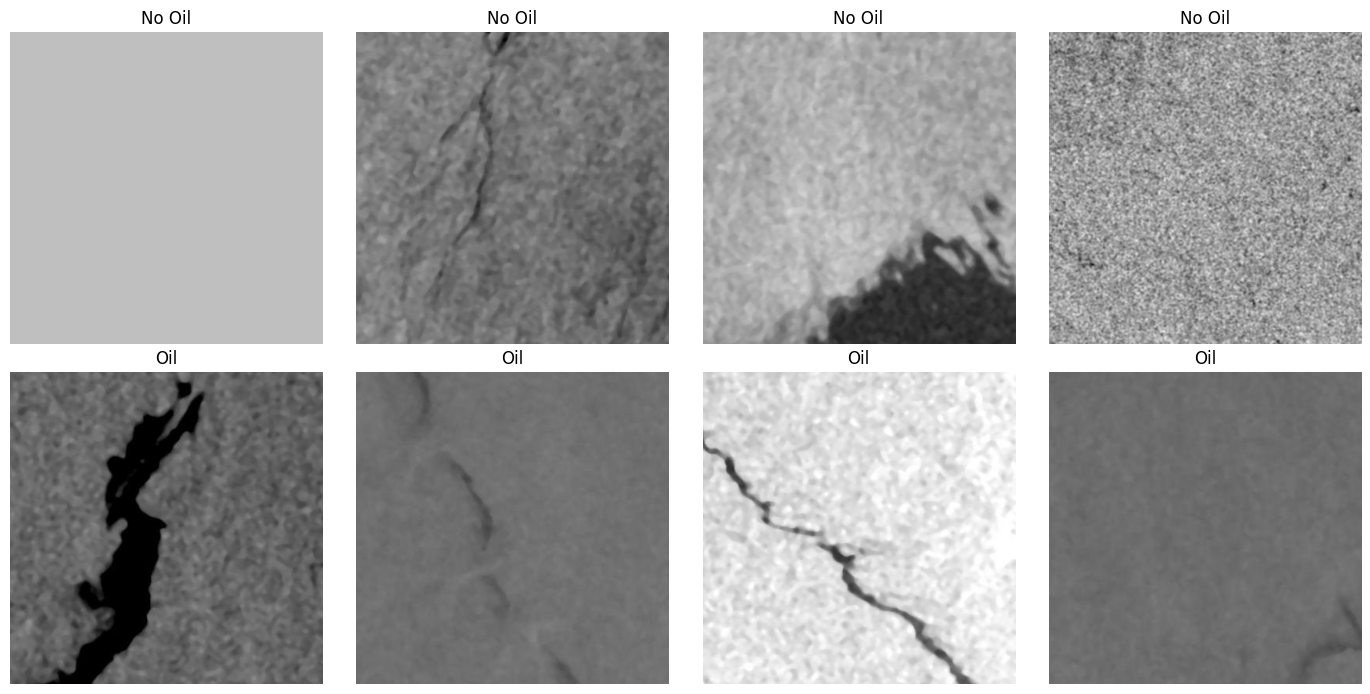

In [36]:
import matplotlib.pyplot as plt
from PIL import Image
import random

no_oil_sample = random.sample(no_oil_paths, 4)
oil_sample = random.sample(clean_class1, 4)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, p in enumerate(no_oil_sample):
    axes[0, i].imshow(Image.open(p), cmap='gray')
    axes[0, i].set_title('No Oil')
    axes[0, i].axis('off')
for i, p in enumerate(oil_sample):
    axes[1, i].imshow(Image.open(p), cmap='gray')
    axes[1, i].set_title('Oil')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

In [37]:
!pip install -q gradio

In [ ]:
# Interactive web demo: upload any SAR image chip, get live classification,
# confidence score, and severity overlay (if oil detected) via analyze_image().
import gradio as gr

def process_upload(img_path):
    r = analyze_image(img_path)
    status = f"🔴 {r['prediction']}" if r['prediction'] == 'Oil Detected' else f"🟢 {r['prediction']}"
    conf_text = f"Confidence: {r['confidence']}%"
    overlay = r['severity_overlay'] if r['severity_overlay'] is not None else r['original']
    return status, conf_text, r['original'], overlay

with gr.Blocks(title="SAR Oil Spill Monitoring") as demo:
    gr.Markdown("# 🛰️ AI-Powered Oil Spill Detection System")
    gr.Markdown("Upload a Sentinel-1 SAR image chip — the system classifies, localizes, and estimates severity in real-time.")

    with gr.Row():
        img_input = gr.Image(type="filepath", label="Upload SAR Image")
        with gr.Column():
            status_output = gr.Textbox(label="Status")
            conf_output = gr.Textbox(label="Confidence")

    with gr.Row():
        original_output = gr.Image(label="Input Image")
        overlay_output = gr.Image(label="Severity Overlay (if oil detected)")

    analyze_btn = gr.Button("Analyze", variant="primary")
    analyze_btn.click(
        fn=process_upload,
        inputs=img_input,
        outputs=[status_output, conf_output, original_output, overlay_output]
    )

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://0ee196eb16d899996e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
